In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
agg_stats = pd.read_parquet('data/processed/aggregate_stats.parquet')
events = pd.read_parquet('data/processed/events.parquet')
reports = pd.read_parquet('data/processed/storm_reports.parquet')

reports_ne = reports[reports['state'].isin(['PA', 'NY', 'NJ', 'CT', 'RI', 'MA', 'VT', 'NH', 'ME'])].reset_index()
ne_wfo = list(reports_ne['wfo'].unique())
# "ALY", "BGM", "BOX", "BTV", "BUF", "CAE", "CAR", "CHS", "CLE", "CTP", "GSP", 
# "GYX", "ILM", "ILN", "LWX", "MHX", "OKX", "PBZ", "PHI", "RAH", "RLX", "RNK", "AKQ"
# ^ wfo in eastern states
# cae, chs, gsp, ilm, iln, lwx, mhx, rah, rlx, rnk, akq
# ^ in eastern states, not in NE states probably

agg_stats_ne = agg_stats[agg_stats['wfo'].isin(ne_wfo)].reset_index()
events_ne = events[events['wfo'].isin(ne_wfo)].reset_index()

,index,report_id,wfo,lsrtype,typetext,magnitude,city,county,state,lat0,lon0,valid,warned,leadtime,remark,source,tdq
0,13635,0,ALY,SV,TSTM WND DMG,NaN,SALISBURY,LITCHFIELD,CT,41.98,-73.42,2008-03-09 00:00:00+00:00,False,NaN,TREE REPORTED DOWN.,PUBLIC,False
1,13636,1,ALY,SV,TSTM WND DMG,NaN,CHESHIRE,BERKSHIRE,MA,42.56,-73.15,2008-03-09 00:07:00+00:00,False,NaN,TREE AND WIRES DOWN.,EMERGENCY MNGR,False
2,13637,2,ALY,SV,TSTM WND DMG,NaN,STOCKBRIDGE,BERKSHIRE,MA,42.29,-73.32,2008-03-09 00:10:00+00:00,False,NaN,LARGE TREE LIMB AND WIRES DOWN,EMERGENCY MNGR,False
3,13638,3,ALY,SV,TSTM WND DMG,NaN,SHEFFIELD,BERKSHIRE,MA,42.11,-73.35,2008-03-09 00:12:00+00:00,False,NaN,TREE REPORTED DOWN.,TRAINED SPOTTER,False
4,13639,4,ALY,SV,TSTM WND DMG,NaN,FALLS VILLAGE,LITCHFIELD,CT,41.95,-73.36,2008-03-09 00:30:00+00:00,False,NaN,SEVERAL TREES DOWN ON RT 7,EMERGENCY MNGR,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67835,547104,840,PHI,SV,TSTM WND DMG,NaN,Mount Arlington,Morris,NJ,40.93,-74.63,2025-12-19 20:25:00+00:00,True,44.0,Numerous 1-3 inch tree limbs downed. Time esti...,Trained Spotter,False
67836,547105,841,PHI,SV,TSTM WND DMG,NaN,Towaco,Morris,NJ,40.92,-74.34,2025-12-19 20:38:00+00:00,True,57.0,"Tree on powerlines, snapping a power pole on T...",Trained Spotter,False
67837,547106,842,PHI,SV,TSTM WND DMG,NaN,Towaco,Morris,NJ,40.92,-74.34,2025-12-19 20:38:00+00:00,True,57.0,Two trees down and branches down along Route 2...,Trained Spotter,False
67838,547107,843,PHI,MA,MARINE TSTM WIND,47.0,Surf City,Ocean,NJ,39.66,-74.17,2025-12-19 21:00:00+00:00,False,NaN,Wunderground station KNJSURFC12 measured gust.,Mesonet,False


In [ ]:
agg_stats_ne[agg_stats_ne['wfo'] == 'CAR']

,index,wfo,year,phenomena,events_total,events_verified,verification_rate,far,pod,csi,area_verify_pct,shared_border_pct,size_poly_vs_county_pct,avg_size_sqkm,avg_leadtime_min,max_leadtime_min,min_leadtime_min,reports_total,unwarned_reports,tdq_stormreports
90,323,CAR,2008,"TO,SV",64,25,0.390625,0.609375,0.461538,0.268336,NaN,NaN,NaN,1758.377755,24.583333,62.0,0.0,104,54,2
91,324,CAR,2009,"TO,SV",55,22,0.400000,0.600000,0.675325,0.335484,NaN,NaN,NaN,2129.233687,25.403846,92.0,2.0,77,25,0
92,325,CAR,2010,"TO,SV",40,19,0.475000,0.525000,0.672727,0.385840,NaN,NaN,NaN,3407.347178,29.837838,65.0,0.0,110,36,0
93,326,CAR,2011,"TO,SV",121,66,0.545455,0.454545,0.757062,0.464203,NaN,NaN,NaN,1932.658567,25.932836,61.0,0.0,177,38,5
94,327,CAR,2012,"TO,SV",42,17,0.404762,0.595238,0.516129,0.293420,NaN,NaN,NaN,2251.323368,22.687500,56.0,4.0,62,30,0
95,328,CAR,2013,"TO,SV",103,51,0.495146,0.504854,0.674847,0.399772,NaN,NaN,NaN,2876.011902,23.427273,59.0,0.0,163,49,4
96,329,CAR,2014,"TO,SV",34,15,0.441176,0.558824,0.837838,0.406469,NaN,NaN,NaN,1402.904670,19.451613,61.0,0.0,37,6,0
97,330,CAR,2015,"TO,SV",79,35,0.443038,0.556962,0.724138,0.379061,NaN,NaN,NaN,2495.856559,19.761905,57.0,0.0,116,32,0
98,331,CAR,2016,"TO,SV",52,37,0.711538,0.288462,0.821705,0.616376,NaN,NaN,NaN,2423.751964,21.084906,57.0,0.0,129,20,3
99,332,CAR,2017,"TO,SV",40,21,0.525000,0.475000,0.741379,0.443735,NaN,NaN,NaN,2239.323654,22.302326,55.0,1.0,58,15,0


In [103]:
events_ne['windtag'].value_counts()

windtag
60.0    15231
70.0      854
50.0      292
80.0       48
Name: count, dtype: int64

In [78]:
events_ne[(events_ne['wfo'] == 'CAR') & (events_ne['year'] == 2025)]

,index,event_id,wfo,phenomena,significance,eventid,year,issue,expire,verify,...,status,fcster,ugc_codes,ugc_names,stormreports,size_reduction_pct,perimeter_ratio,geometry,month,season
12125,48699,2025CAR1SVW1,CAR,SV,W,1,2025,2025-05-16 19:58:00+00:00,2025-05-16 20:45:00+00:00,False,...,EXP,LaFlash,[MEC003],[Aroostook ME],,97.698223,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,5,MAM
12126,48700,2025CAR2SVW1,CAR,SV,W,2,2025,2025-06-05 21:18:00+00:00,2025-06-05 22:00:00+00:00,True,...,EXP,MStrauser,"[MEC019, MEC021]","[Penobscot ME, Piscataquis ME]","16,17",92.315168,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,6,JJA
12127,48701,2025CAR3SVW1,CAR,SV,W,3,2025,2025-06-05 21:58:00+00:00,2025-06-05 23:00:00+00:00,True,...,EXP,MStrauser,"[MEC003, MEC019]","[Aroostook ME, Penobscot ME]","18,19,20,22,23,24,25,26",92.534342,0.0,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",6,JJA
12128,48702,2025CAR4SVW1,CAR,SV,W,4,2025,2025-06-19 22:10:00+00:00,2025-06-19 23:15:00+00:00,False,...,CON,Norcross,"[MEC021, MEC025]","[Piscataquis ME, Somerset ME]",,91.350031,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,6,JJA
12129,48703,2025CAR5SVW1,CAR,SV,W,5,2025,2025-06-19 23:14:00+00:00,2025-06-20 00:15:00+00:00,False,...,EXP,Norcross,"[MEC019, MEC021]","[Penobscot ME, Piscataquis ME]",,77.484498,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,6,JJA
12130,48704,2025CAR6SVW1,CAR,SV,W,6,2025,2025-06-19 23:23:00+00:00,2025-06-20 00:30:00+00:00,False,...,EXP,Norcross,"[MEC019, MEC021]","[Penobscot ME, Piscataquis ME]",,76.239061,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,6,JJA
12131,48705,2025CAR7SVW1,CAR,SV,W,7,2025,2025-06-20 00:43:00+00:00,2025-06-20 01:45:00+00:00,False,...,EXP,Norcross,"[MEC019, MEC021]","[Penobscot ME, Piscataquis ME]",,78.686120,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,6,JJA
12132,48706,2025CAR8SVW1,CAR,SV,W,8,2025,2025-06-24 01:48:00+00:00,2025-06-24 02:45:00+00:00,False,...,EXP,Clark,"[MEC025, MEC003, MEC021]","[Somerset ME, Aroostook ME, Piscataquis ME]",,87.680148,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,6,JJA
12133,48707,2025CAR9SVW1,CAR,SV,W,9,2025,2025-07-03 14:04:00+00:00,2025-07-03 15:00:00+00:00,False,...,CON,Norcross,"[MEC003, MEC025]","[Aroostook ME, Somerset ME]",,88.453649,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,7,JJA
12134,48708,2025CAR10SVW1,CAR,SV,W,10,2025,2025-07-03 14:29:00+00:00,2025-07-03 15:15:00+00:00,False,...,EXP,MStrauser,"[MEC021, MEC025]","[Piscataquis ME, Somerset ME]",,91.511676,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,7,JJA


In [95]:
reports_ne[(reports_ne['wfo'] == 'CAR')]['typetext'].value_counts()

typetext
TSTM WND DMG        1085
HAIL                 229
FLASH FLOOD          208
ICE JAM               32
TSTM WND GST          30
TORNADO               24
ICE JAM FLOODING       4
MARINE TSTM WIND       3
DEBRIS FLOW            1
Name: count, dtype: int64

In [97]:
reports_ne[(reports_ne['wfo'] == 'CAR') & (reports_ne['valid'].dt.year == 2025)]['typetext'].value_counts()

typetext
TSTM WND DMG        44
ICE JAM             13
ICE JAM FLOODING     4
HAIL                 4
FLASH FLOOD          4
TSTM WND GST         1
MARINE TSTM WIND     1
Name: count, dtype: int64

In [112]:
reports_num_filtered = reports_ne[reports_ne['remark'].str.contains('mph')].reset_index()

In [94]:
reports_ne[(reports_ne['wfo'] == 'CAR') & (reports_ne['valid'].dt.year == 2025)]

,index,report_id,wfo,lsrtype,typetext,magnitude,city,county,state,lat0,lon0,valid,warned,leadtime,remark,source,tdq
30418,87116,0,CAR,FF,ICE JAM,NaN,2 WSW Allagash,Aroostook,ME,47.07,-69.07,2025-01-10 13:54:00+00:00,False,NaN,Delayed report. Photos via Social Media confir...,Trained Spotter,False
30419,87117,1,CAR,FF,ICE JAM,NaN,1 NW Allagash,Aroostook,ME,47.09,-69.05,2025-01-11 18:52:00+00:00,False,NaN,Update to ice jam which remains on the Allagas...,NWS Employee,False
30420,87118,2,CAR,FF,ICE JAM,NaN,Dennysville,Washington,ME,44.90,-67.23,2025-03-07 12:00:00+00:00,False,NaN,Photo of an ice jam on Dennys River looking so...,Public,False
30421,87119,3,CAR,FF,ICE JAM,NaN,Masardis,Aroostook,ME,46.50,-68.36,2025-03-18 14:53:00+00:00,False,NaN,Quarter mile long ice jam. Just below the conf...,NWS Employee,False
30422,87120,4,CAR,FF,ICE JAM FLOODING,NaN,1 NE Milo,Piscataquis,ME,45.27,-68.97,2025-03-18 17:08:00+00:00,False,NaN,Piscataquis County EMA reporting an Ice Jam at...,Emergency Mngr,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30484,87182,66,CAR,SV,TSTM WND DMG,NaN,3 SSW Calais,Washington,ME,45.14,-67.30,2025-08-14 21:25:00+00:00,True,6.0,Social media report of numerous pine trees dow...,Public,False
30485,87183,67,CAR,SV,TSTM WND DMG,NaN,Princeton,Washington,ME,45.22,-67.58,2025-08-14 21:29:00+00:00,False,NaN,Washington County Emergency Management reports...,Emergency Mngr,False
30486,87184,68,CAR,SV,TSTM WND DMG,NaN,1 S Old Town,Penobscot,ME,44.92,-68.65,2025-08-17 19:11:00+00:00,False,NaN,Fire department reports 1 tree down which took...,Fire Dept/Rescue,False
30487,87185,69,CAR,MA,MARINE TSTM WIND,39.0,16 SE Frenchboro,ANZ051,ME,43.97,-68.13,2025-10-20 21:00:00+00:00,False,NaN,Mesonet station MDRM1 15 ESE Frenchboro.,Mesonet,False


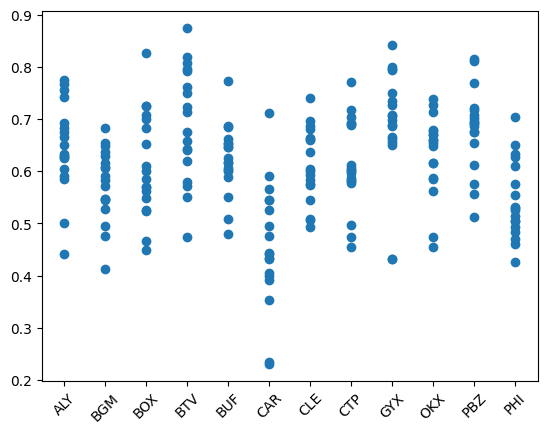

In [ ]:
# scatter plot of the verification rates of wfos in the NE states
plt.scatter(agg_stats_ne['wfo'], agg_stats_ne['verification_rate'])
plt.xticks(rotation=45)
plt.show()

In [35]:
type_counts = reports_ne.groupby(['state', 'typetext'])['typetext'].count().unstack()
row_total = type_counts.sum(axis=1)
type_counts_norm = type_counts.div(row_total, axis=0)
type_counts_norm

typetext,DEBRIS FLOW,FLASH FLOOD,HAIL,ICE JAM,ICE JAM FLOODING,LANDSLIDE,LANDSPOUT,MARINE HAIL,MARINE TSTM WIND,SNOW SQUALL,TORNADO,TSTM WND DMG,TSTM WND GST,WATER SPOUT,WATERSPOUT
state,,,,,,,,,,,,,,,
CT,NaN,0.147121,0.089537,NaN,NaN,NaN,NaN,0.000702,0.083216,NaN,0.016503,0.641503,0.020365,0.000351,0.000702
MA,NaN,0.119927,0.080842,NaN,NaN,NaN,NaN,0.000835,0.028729,0.002171,0.012694,0.726073,0.026558,0.001503,0.000668
ME,0.000279,0.119799,0.147724,0.010053,0.001117,0.000279,NaN,0.001117,0.023178,0.010612,0.015359,0.647026,0.021502,0.000559,0.001396
NH,NaN,0.134213,0.169617,0.000322,NaN,0.000644,NaN,0.000322,0.011587,0.019311,0.009656,0.639202,0.014483,0.000644,NaN
NJ,NaN,0.205759,0.051609,NaN,NaN,NaN,0.000272,NaN,0.153198,0.000272,0.007741,0.505229,0.071031,0.003939,0.000951
NY,0.000300,0.159614,0.103391,0.000100,NaN,0.000050,0.000050,0.000300,0.063675,0.005602,0.011054,0.623149,0.027711,0.003701,0.001301
PA,0.000498,0.179809,0.093800,0.000045,NaN,0.000408,0.000136,NaN,0.001585,0.004076,0.017619,0.676661,0.023008,0.001902,0.000453
RI,NaN,0.167845,0.113074,NaN,NaN,NaN,NaN,NaN,0.123675,NaN,0.014134,0.512367,0.056537,0.012367,NaN
VT,NaN,0.215796,0.155805,0.001295,0.000863,0.001295,NaN,NaN,0.000432,0.016832,0.005179,0.587397,0.015106,NaN,NaN


<Axes: xlabel='typetext', ylabel='state'>

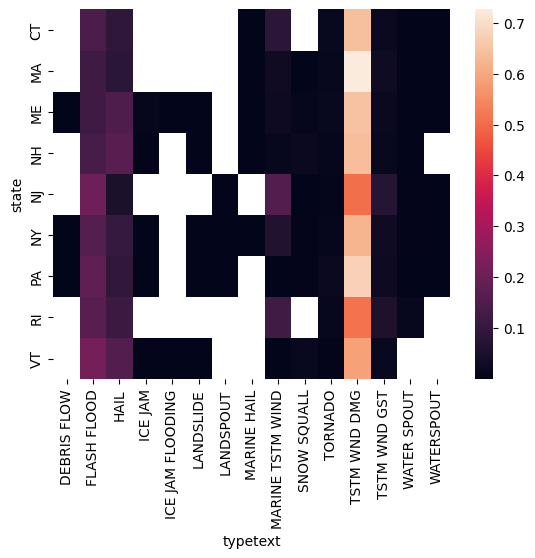

In [36]:
sns.heatmap(type_counts_norm)

In [133]:
rep_true = rep_filtered[['lat0', 'lon0', 'typetext', 'warned']]
rep_true = rep_true[rep_true['warned'] == True]
rep_false = rep_filtered[['lat0', 'lon0', 'typetext', 'warned']]
rep_false = rep_false[rep_false['warned'] == False]

In [134]:
# Sample data: list of dictionaries or a pandas DataFrame
data = rep_true
df = pd.DataFrame(data)

# Create the scatter map
fig = px.scatter_geo(df, 
                     lat='lat0', 
                     lon='lon0', 
                    #  color="warned",
                     hover_name="typetext",
                    )

fig.update_layout(
    geo = dict(
        showframe=False,
        showcountries=True,
        projection_type="mercator",
        lataxis_range=[20, 55],
        lonaxis_range=[-130, -60],
    ),
    dragmode=False,
)

fig.show(
    config={'scrollZoom': False}
    )

In [136]:
# Sample data: list of dictionaries or a pandas DataFrame
data = rep_false
df = pd.DataFrame(data)

# Create the scatter map
fig = px.scatter_geo(df, 
                     lat='lat0', 
                     lon='lon0', 
                    #  color="warned",
                     hover_name="typetext",
                    )

fig.update_layout(
    geo = dict(
        showframe=False,
        showcountries=True,
        projection_type="mercator",
        lataxis_range=[20, 55],
        lonaxis_range=[-130, -60],
    ),
    dragmode=False,
)
fig.update_traces(marker=dict(color='red'))

fig.show(
    config={'scrollZoom': False}
    )

In [119]:
reports_num_filtered['typetext'].value_counts()

typetext
SNOW SQUALL         96
TSTM WND GST        59
TORNADO             52
TSTM WND DMG        46
MARINE TSTM WIND    22
HAIL                 6
FLASH FLOOD          1
Name: count, dtype: int64

In [120]:
rep_filtered = reports[reports['remark'].str.contains('mph')].reset_index()